In [ ]:
from importlib import reload
import MLPModel, LinearModel 
import Model_Training
import numpy as np

reload(MLPModel)
reload(LinearModel)
reload(Model_Training)

import torch
seed = 55
torch.manual_seed(seed)


In [ ]:


ticker = "AAPL"
start = '2019-01-01'    # start date
end  = '2026-01-01'     # end date
interval = '1d'         # interval
train_ratio = 0.75
no_epoches = 100_000
lr = 0.0001
tx_fees_bpts = 10
threshold = 0.001

weight_decay = 5e-3

max_lags = 32

modelMLP = MLPModel.MLP # multiplayer perception 

Model = Model_Training.model_training(model = modelMLP(max_lags),
                              tick = ticker,
                              start = start,
                              end = end ,
                              interval = interval,
                              train_ratio = train_ratio,
                              max_lags = max_lags,
                              no_epochs=no_epoches,
                              lr = lr,
                              rtol = 1e-5,
                              trade_signal = "threshold",
                              threshold=threshold,
                              transaction_cost_bpts= tx_fees_bpts,
                              verbose = True,
                              weight_decay= weight_decay)

modelLinear = LinearModel.LinearModel # Linear Model equivalent to AR tine series

ModelLin = Model_Training.model_training(model = modelLinear(max_lags),
                              tick = ticker,
                              start = start,
                              end = end ,
                              interval = interval,
                              train_ratio = train_ratio,
                              max_lags = max_lags,
                              no_epochs=no_epoches,
                              lr = lr,
                              rtol = 1e-5 ,
                              trade_signal = "threshold",
                              threshold=threshold,
                              transaction_cost_bpts= tx_fees_bpts,
                              verbose = True,
                              weight_decay= weight_decay)



[*********************100%***********************]  1 of 1 completed



Training model...
Epoch 0/100000, Loss = 1.053292394
Epoch 500/100000, Loss = 0.976252258
Epoch 1000/100000, Loss = 0.935696304
Epoch 1500/100000, Loss = 0.884558976
Epoch 2000/100000, Loss = 0.822648346
Epoch 2500/100000, Loss = 0.762429535
Epoch 3000/100000, Loss = 0.715434015
Epoch 3500/100000, Loss = 0.674943745
Epoch 4000/100000, Loss = 0.647163570
Epoch 4500/100000, Loss = 0.627940953
Epoch 5000/100000, Loss = 0.612242639
Epoch 5500/100000, Loss = 0.599807501
Epoch 6000/100000, Loss = 0.587704003
Epoch 6500/100000, Loss = 0.576959908
Epoch 7000/100000, Loss = 0.563400328
Epoch 7500/100000, Loss = 0.549800277


[*********************100%***********************]  1 of 1 completed

Epoch 8000/100000, Loss = 0.539344251
Epoch 8500/100000, Loss = 0.530586481
Relative Tolance Reached at Epoch 8568

 Training Finished! 
 Loss = 0.529905975
Test Loss = 1.251090407

Test Loss = 0.000492744 
Train Loss = 0.000208701



Training model...
Epoch 0/100000, Loss = 1.233997703
Epoch 500/100000, Loss = 1.061028600
Epoch 1000/100000, Loss = 0.984597862
Epoch 1500/100000, Loss = 0.952793837
Epoch 2000/100000, Loss = 0.940720022
Relative Tolance Reached at Epoch 2179

 Training Finished! 
 Loss = 0.938662946
Test Loss = 0.895122886

Test Loss = 0.000352546 
Train Loss = 0.000369690



Test Loss = 0.000492744 
Train Loss = 0.000208701

Test Loss = 0.000352546 
Train Loss = 0.000369690


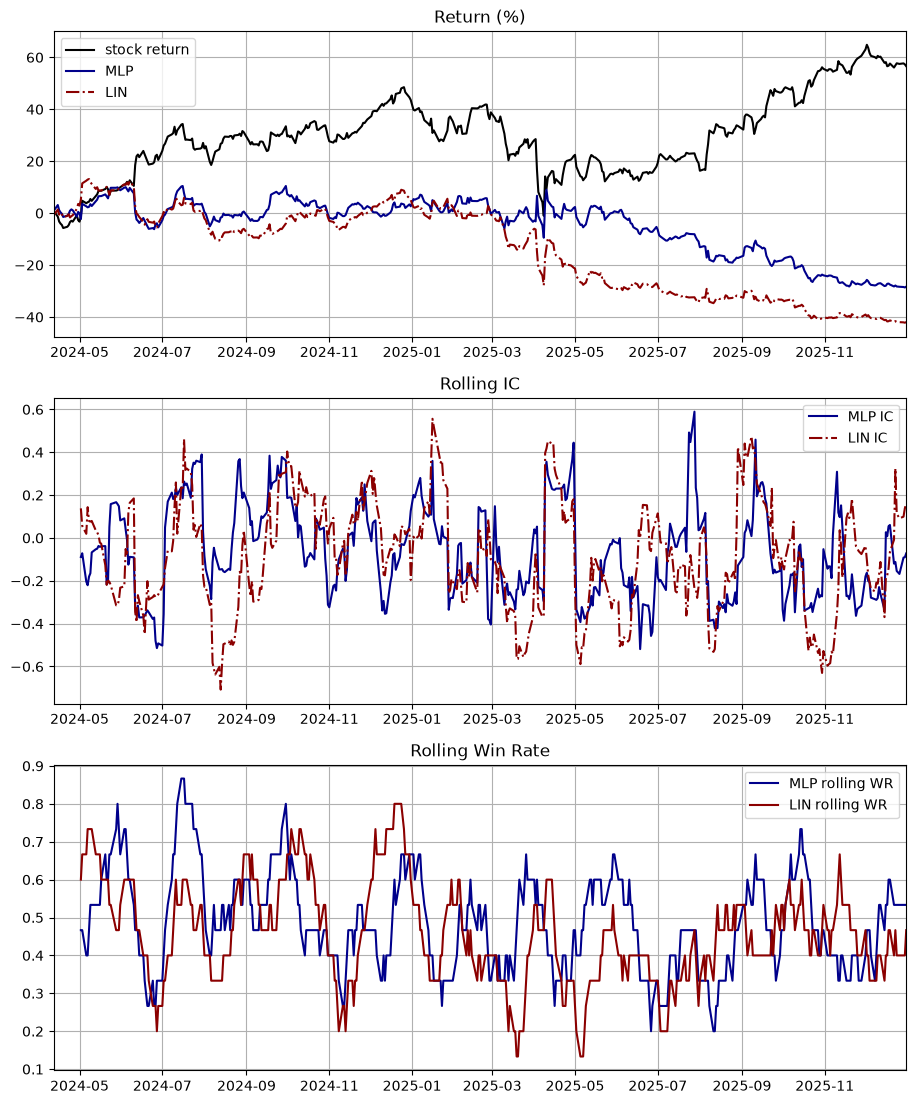

In [ ]:
# Plot the Model return, rolling IC, and rolling win rate 
fx_fees_bpts = 0
threshold = 0.0000#0.0000001

window = Model.rolling_window
Model.get_MR_results()
MR_df = Model.MR_df
MR_cum_return = np.expm1(MR_df["trade_log_return_cum"]) * 100



import matplotlib.pyplot as plt
fig, (ax1,ax2,ax3) = plt.subplots(3,1, figsize = (11, 13.5))

Model.get_trade_results(trade_signal="threshold",
                        threshold=threshold, 
                        transaction_fees_bpts= fx_fees_bpts,
                        window = window  )

ModelLin.get_trade_results(trade_signal="threshold",
                           threshold=threshold, 
                           transaction_fees_bpts= fx_fees_bpts, 
                           window = window)

df_MLP = Model.trade_results
df_LIN = ModelLin.trade_results

dates = Model.date_test
return_MLP = np.expm1(df_MLP["trade_log_return_cum"]) * 100
return_stock = np.expm1(Model.T_test.squeeze().numpy().cumsum()) * 100
return_LIN = np.expm1(df_LIN["trade_log_return_cum"]) * 100

# ax1.plot(dates,MR_cum_return,c='green',label='Mean Reversion',ls='dotted')


ax1.plot(dates, return_stock, c='black',label="stock return")
ax1.plot(dates, return_MLP, c='darkred',label='MLP')
ax1.plot(dates, return_LIN, c='darkblue',label='LIN',ls='-.')

ax1.grid()

ax1.set_title("Return (%)")
ax1.legend()


# Plot rolling IC

df = Model.trade_results

win_idx = window//2 
Model.get_model_performance(df)
rolling_ic_MLP = df["rolling_IC"].dropna()

rolling_WR_MLP = df["is_won"].rolling(window = window, min_periods=window).mean().dropna()
df = ModelLin.trade_results
ModelLin.get_model_performance(df)
rolling_ic_LIN = df["rolling_IC"].dropna()
rolling_WR_LIN = df["is_won"].rolling(window = window, min_periods=window).mean().dropna()

ax2.plot(Model.date_test[window-1:], rolling_ic_MLP, c='darkred', label='MLP IC')
ax2.plot(Model.date_test[window-1:], rolling_ic_LIN, c='darkblue', label='LIN IC',ls='-.')
ax2.grid()
ax2.set_title("Rolling IC")
ax2.legend()


# Rolling winrate 
# rolling_WR = df["is_won"].rolling(window = window, min_periods=window).mean()

ax3.set_title("Rolling Win Rate")

ax3.plot(dates[window-1:], rolling_WR_MLP, c='darkred',label='MLP rolling WR')
ax3.plot(dates[window-1:], rolling_WR_LIN, c='darkblue',label='LIN rolling WR')
ax3.legend()
ax3.grid()

for ax in (ax1,ax2,ax3):
    ax.set_xlim(Model.date_test[0], Model.date_test[-1])



# Model.date_test

In [ ]:
df["is_won"].mean()

np.float64(0.45601851851851855)

In [ ]:
window

15

Overall IC: -0.028976323244462796
Mean rolling IC: -0.06509033132839694
Positive-window fraction: 0.37320574162679426
Minimum: -0.5188109660420672
Maximum: 0.5894182794655934
Win_Rate: 0    0.486111
Name: win_rate, dtype: float64

Overall IC: -0.09117209772977841
Mean rolling IC: -0.08923844203302253
Positive-window fraction: 0.37559808612440193
Minimum: -0.7079945766066834
Maximum: 0.5561915629243067
Win_Rate: 0    0.456019
Name: win_rate, dtype: float64


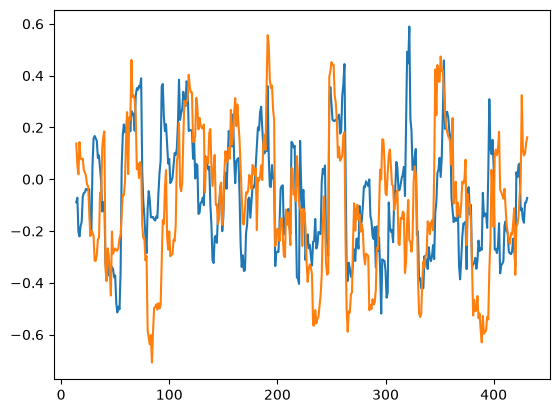

In [ ]:

df = Model.trade_results
Model.get_model_performance(df)

rolling_ic = df["rolling_IC"].dropna()
df["rolling_IC"].plot(x=Model.date_test)

print("Overall IC:", df["T_hat"].corr(df["T_test"]))
print("Mean rolling IC:", rolling_ic.mean())
print("Positive-window fraction:", (rolling_ic > 0).mean())
print("Minimum:", rolling_ic.min())
print("Maximum:", rolling_ic.max())
print("Win_Rate:", Model.performance_df["win_rate"])



df = ModelLin.trade_results
ModelLin.get_model_performance(df)

rolling_ic = df["rolling_IC"].dropna()
df["rolling_IC"].plot(x=Model.date_test)

print("\nOverall IC:", df["T_hat"].corr(df["T_test"]))
print("Mean rolling IC:", rolling_ic.mean())
print("Positive-window fraction:", (rolling_ic > 0).mean())
print("Minimum:", rolling_ic.min())
print("Maximum:", rolling_ic.max())
print("Win_Rate:", ModelLin.performance_df["win_rate"])